# 패키지 임포트

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import warnings
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import roc_curve, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings(action='ignore') 

from MulticoreTSNE import MulticoreTSNE as TSNE

USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
print("Using Device:", DEVICE)

Using Device: cuda


In [3]:
fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 이 폰트의 원하는 이름 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic'}) # 폰트 설정

# 데이터 관리

In [4]:
df = pd.read_csv('./전체 통합 데이터_전처리 완료.csv')
dataDF = pd.DataFrame(data=df)
df.head()

,기기명,저장시간,기계동작시간,형폐시간,이젝터 전진시간,이젝터 후진시간,사출시간(충진시간),보압시간,계량시간,사출 최대압력,보압절환압력,냉각시간
0,HK1,2022-01-01 22:55:44,67.675241,4.050239,0.612456,0.63564,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337
1,HK1,2022-01-01 22:55:45,67.675241,4.050239,0.612456,0.63564,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337
2,HK1,2022-01-01 22:55:46,67.675241,4.050239,0.612456,0.63564,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337
3,HK1,2022-01-01 22:55:47,67.675241,4.050239,0.612456,0.63564,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337
4,HK1,2022-01-01 22:55:48,67.675241,4.050239,0.612456,0.63564,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3165639 entries, 0 to 3165638
Data columns (total 12 columns):
 #   Column      Dtype  
---  ------      -----  
 0   기기명         object 
 1   저장시간        object 
 2   기계동작시간      float64
 3   형폐시간        float64
 4   이젝터 전진시간    float64
 5   이젝터 후진시간    float64
 6   사출시간(충진시간)  float64
 7   보압시간        float64
 8   계량시간        float64
 9   사출 최대압력     float64
 10  보압절환압력      float64
 11  냉각시간        float64
dtypes: float64(10), object(2)
memory usage: 289.8+ MB


In [6]:
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,기계동작시간,형폐시간,이젝터 전진시간,이젝터 후진시간,사출시간(충진시간),보압시간,계량시간,사출 최대압력,보압절환압력,냉각시간
count,3165639.00,3165639.00,3165639.00,3165639.00,3165639.00,3165639.00,3165639.00,3165639.00,3165639.00,3165639.00
mean,64.28,3.89,0.60,0.63,2.77,4.14,15.96,927.69,679.39,27.31
std,15.46,0.51,0.04,0.05,1.58,1.75,11.51,81.11,153.81,6.04
min,15.24,1.80,0.00,0.00,0.01,0.00,0.00,9.90,9.80,5.00
25%,60.04,4.05,0.61,0.64,1.63,3.00,4.61,893.40,554.70,29.21
50%,70.22,4.05,0.61,0.64,1.86,5.00,17.52,929.60,701.20,29.21
75%,74.88,4.05,0.61,0.64,5.00,5.00,23.62,957.40,774.10,29.21
max,866.98,5.79,0.81,0.80,6.00,6.00,120.00,1736.67,1569.12,60.00


In [12]:
df.drop(['저장시간','형폐시간', '냉각시간'], inplace=True, axis=1)

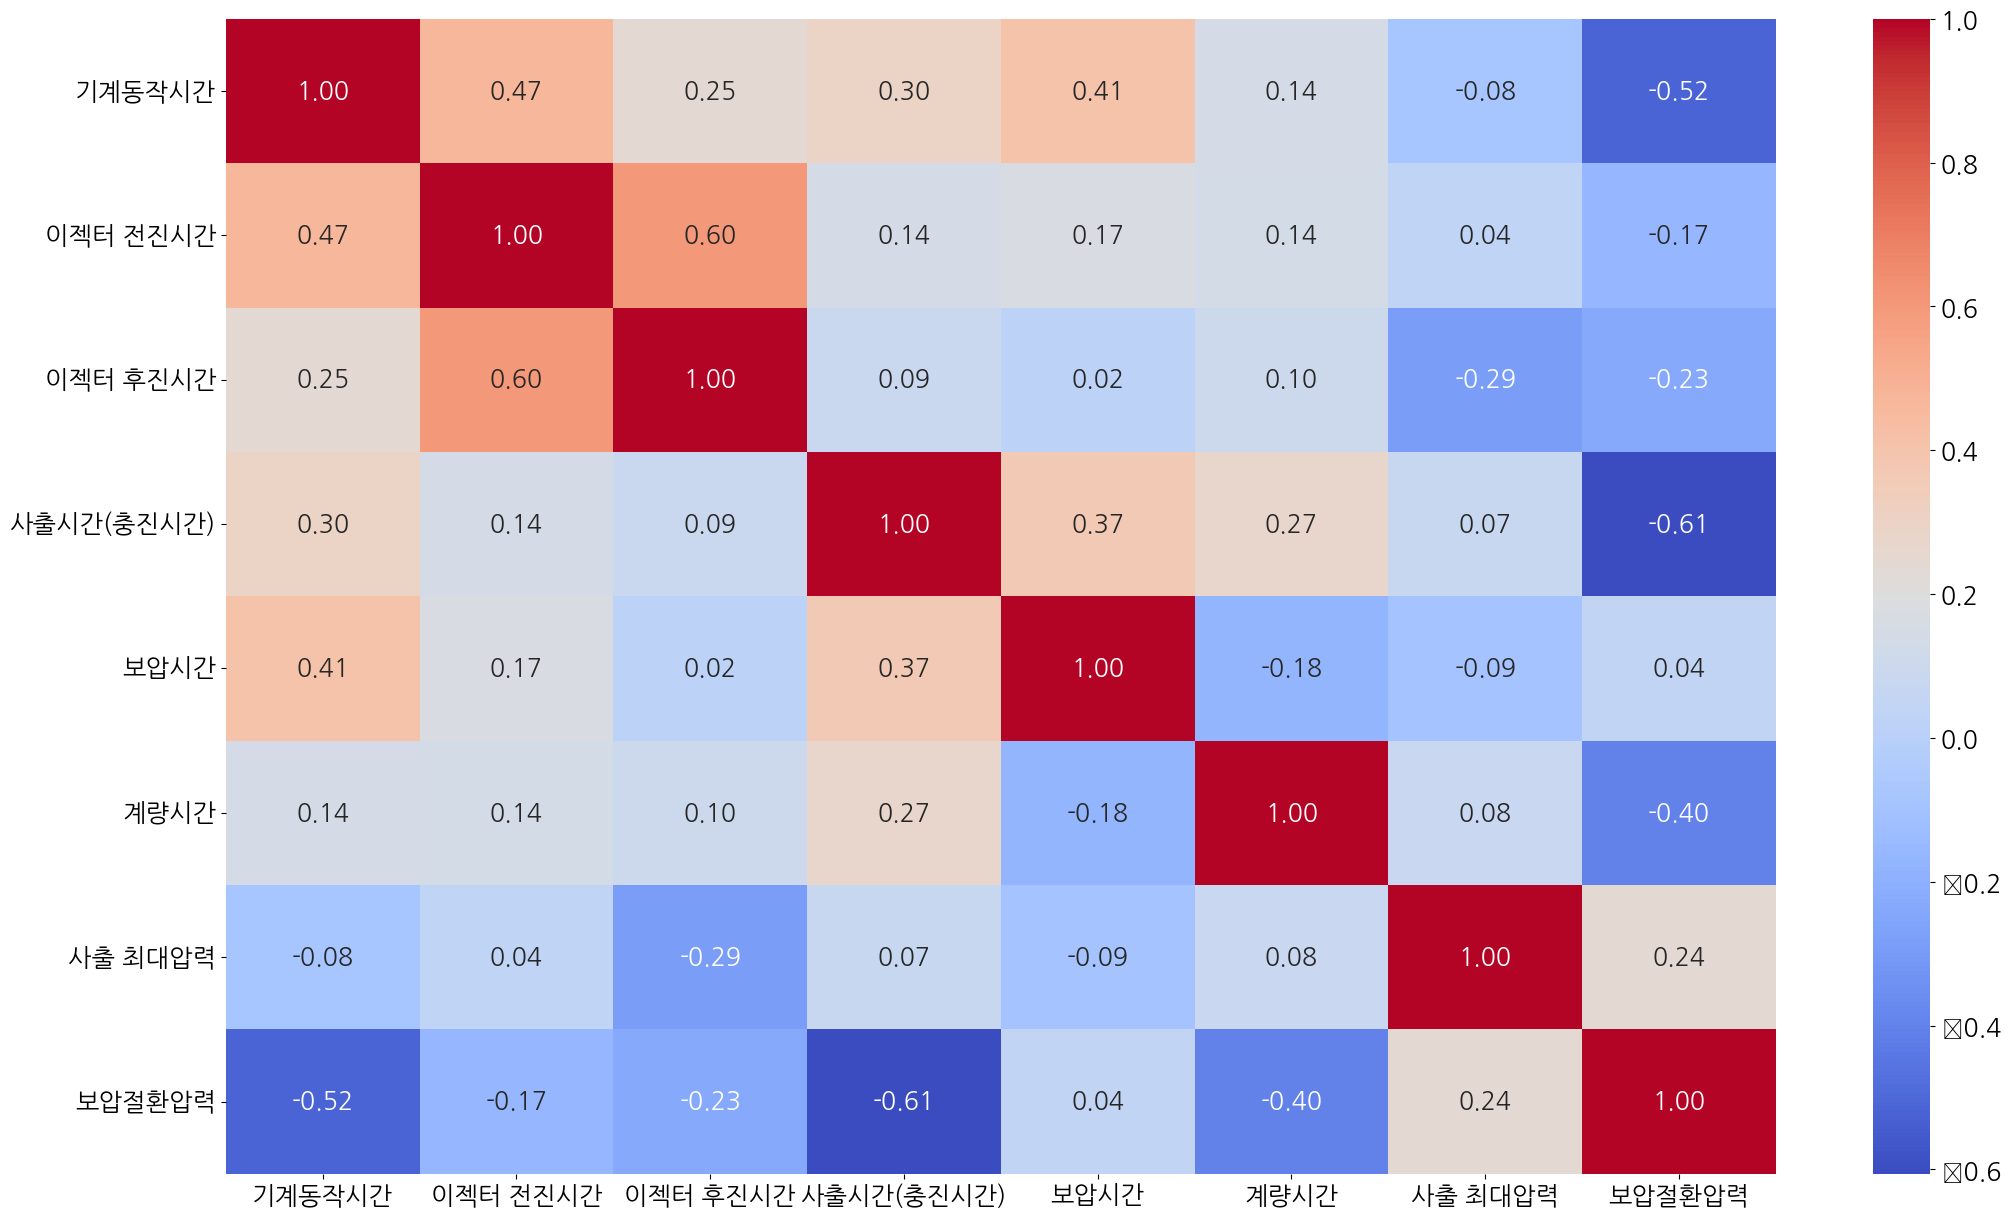

In [44]:
plt.figure(figsize=(25,15))
target_cor = df.corr()
sns.heatmap(target_cor, annot=True, fmt=".2f", cmap ='coolwarm')
plt.savefig('savefig_peerson.png')
plt.show()

In [45]:
df['기기명'].unique()

KeyError: '기기명'

In [17]:
dataDF_outdate = dataDF_outdate.interpolate(method='linear')

In [18]:
dataDF_outdate

,저장시간,기계동작시간,형폐시간,이젝터 전진시간,이젝터 후진시간,사출시간(충진시간),보압시간,계량시간,사출 최대압력,보압절환압력,냉각시간
0,2022-01-01 22:55:44,67.675241,4.050239,0.612456,0.635640,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337
1,2022-01-01 22:55:45,67.675241,4.050239,0.612456,0.635640,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337
2,2022-01-01 22:55:46,67.675241,4.050239,0.612456,0.635640,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337
3,2022-01-01 22:55:47,67.675241,4.050239,0.612456,0.635640,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337
4,2022-01-01 22:55:48,67.675241,4.050239,0.612456,0.635640,2.76703,4.416039,16.890141,921.633773,669.72678,29.21337
...,...,...,...,...,...,...,...,...,...,...,...
3165634,2022-11-04 16:29:14,31.060100,3.887510,0.736395,0.736405,2.00042,1.000860,4.311560,845.326000,738.38200,14.00000
3165635,2022-11-04 16:29:45,31.079700,3.888410,0.737687,0.736369,2.00051,1.000820,4.342670,844.694000,738.50800,14.00000
3165636,2022-11-04 16:30:16,31.061100,3.888390,0.736379,0.736365,2.00026,1.000010,4.321720,844.821000,738.50800,14.00000
3165637,2022-11-04 16:30:48,31.099900,3.887540,0.736449,0.736224,3.00040,1.001040,4.428520,844.694000,741.79100,14.00000


In [57]:
dfTT1.shape

(54903, 11)

In [178]:
dfTT1 = df[df['기기명'] == 'TT1']

In [179]:
dfTT1.drop(['기기명','설비 이상신호'], inplace=True, axis=1)

In [180]:
dfTT1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87675 entries, 2828563 to 2916237
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   기계동작시간      87675 non-null  float64
 1   이젝터 전진시간    87675 non-null  float64
 2   이젝터 후진시간    87675 non-null  float64
 3   사출시간(충진시간)  87675 non-null  float64
 4   보압시간        87675 non-null  float64
 5   계량시간        87675 non-null  float64
 6   사출 최대압력     87675 non-null  float64
 7   보압절환압력      87675 non-null  float64
dtypes: float64(8)
memory usage: 6.0 MB


# 데이터 시각화

## box Plot

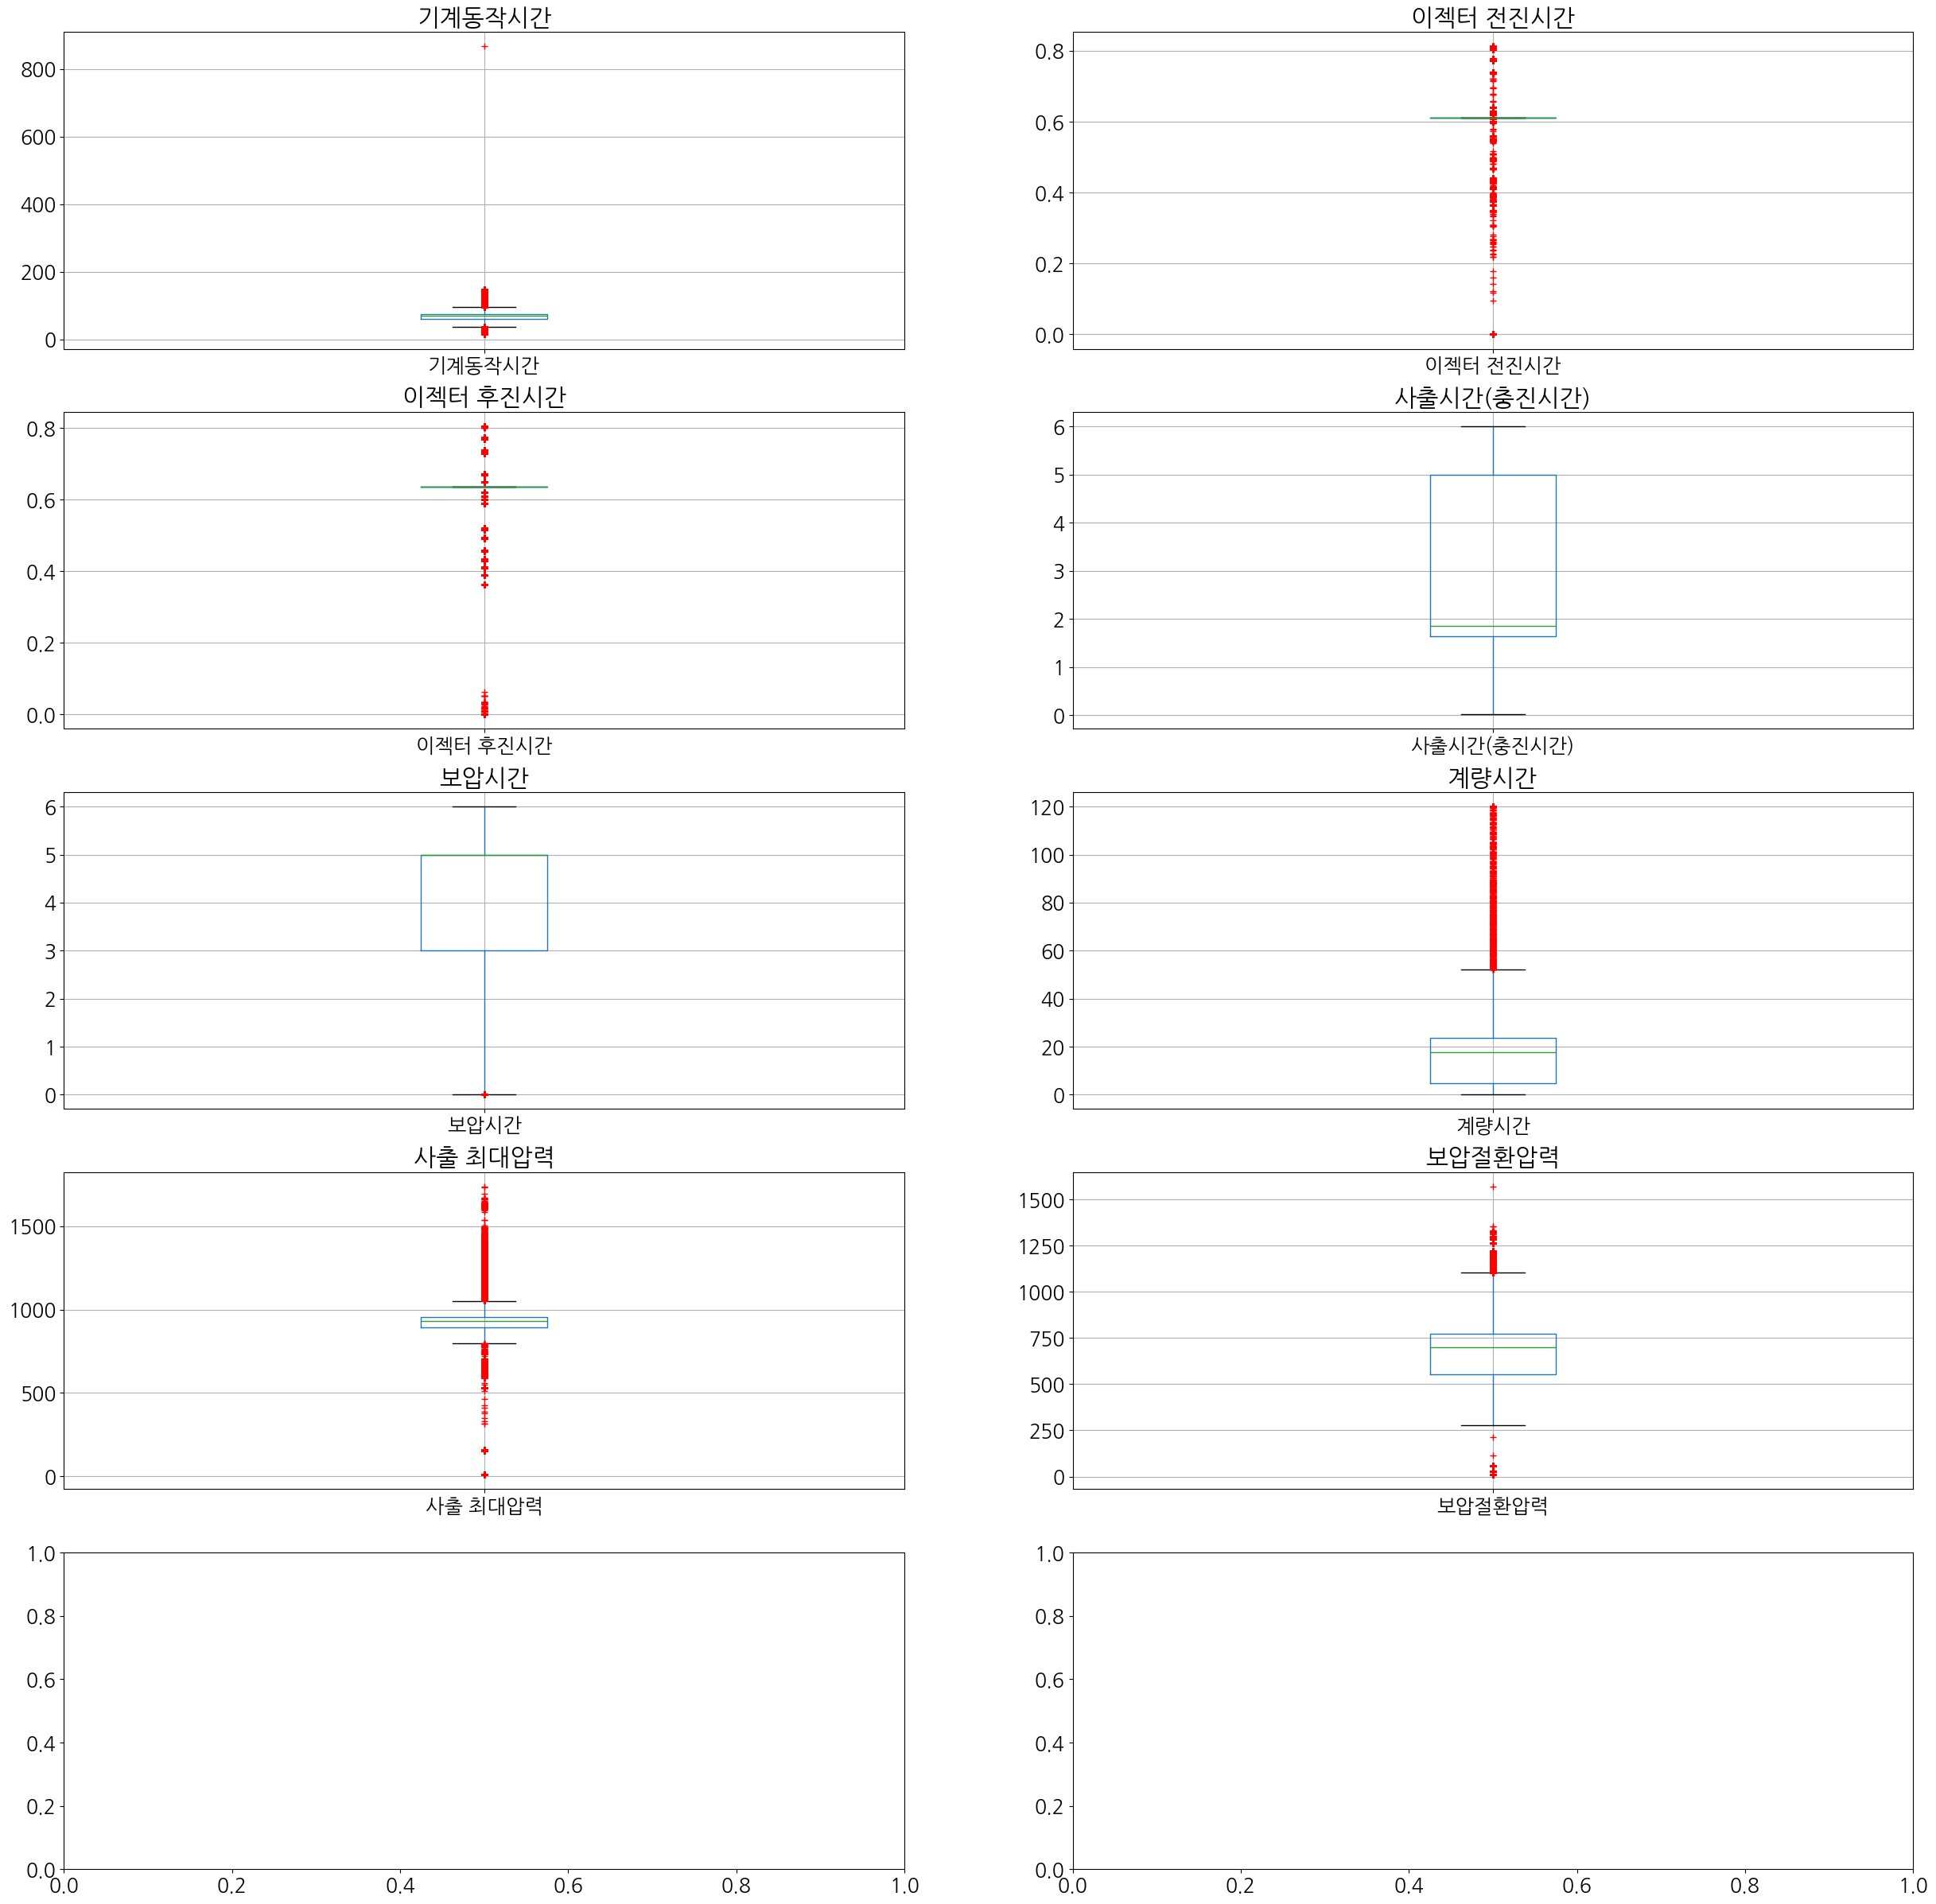

In [181]:
fig, axes = plt.subplots(5, 2, figsize=(30, 30))

# 각 열에 대한 박스플롯 그리기
for i, column in enumerate(dfTT1.columns):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    dataDF_outdate.boxplot(column, ax=ax,sym='r+')
    ax.set_title(column)

## 선형 그래프

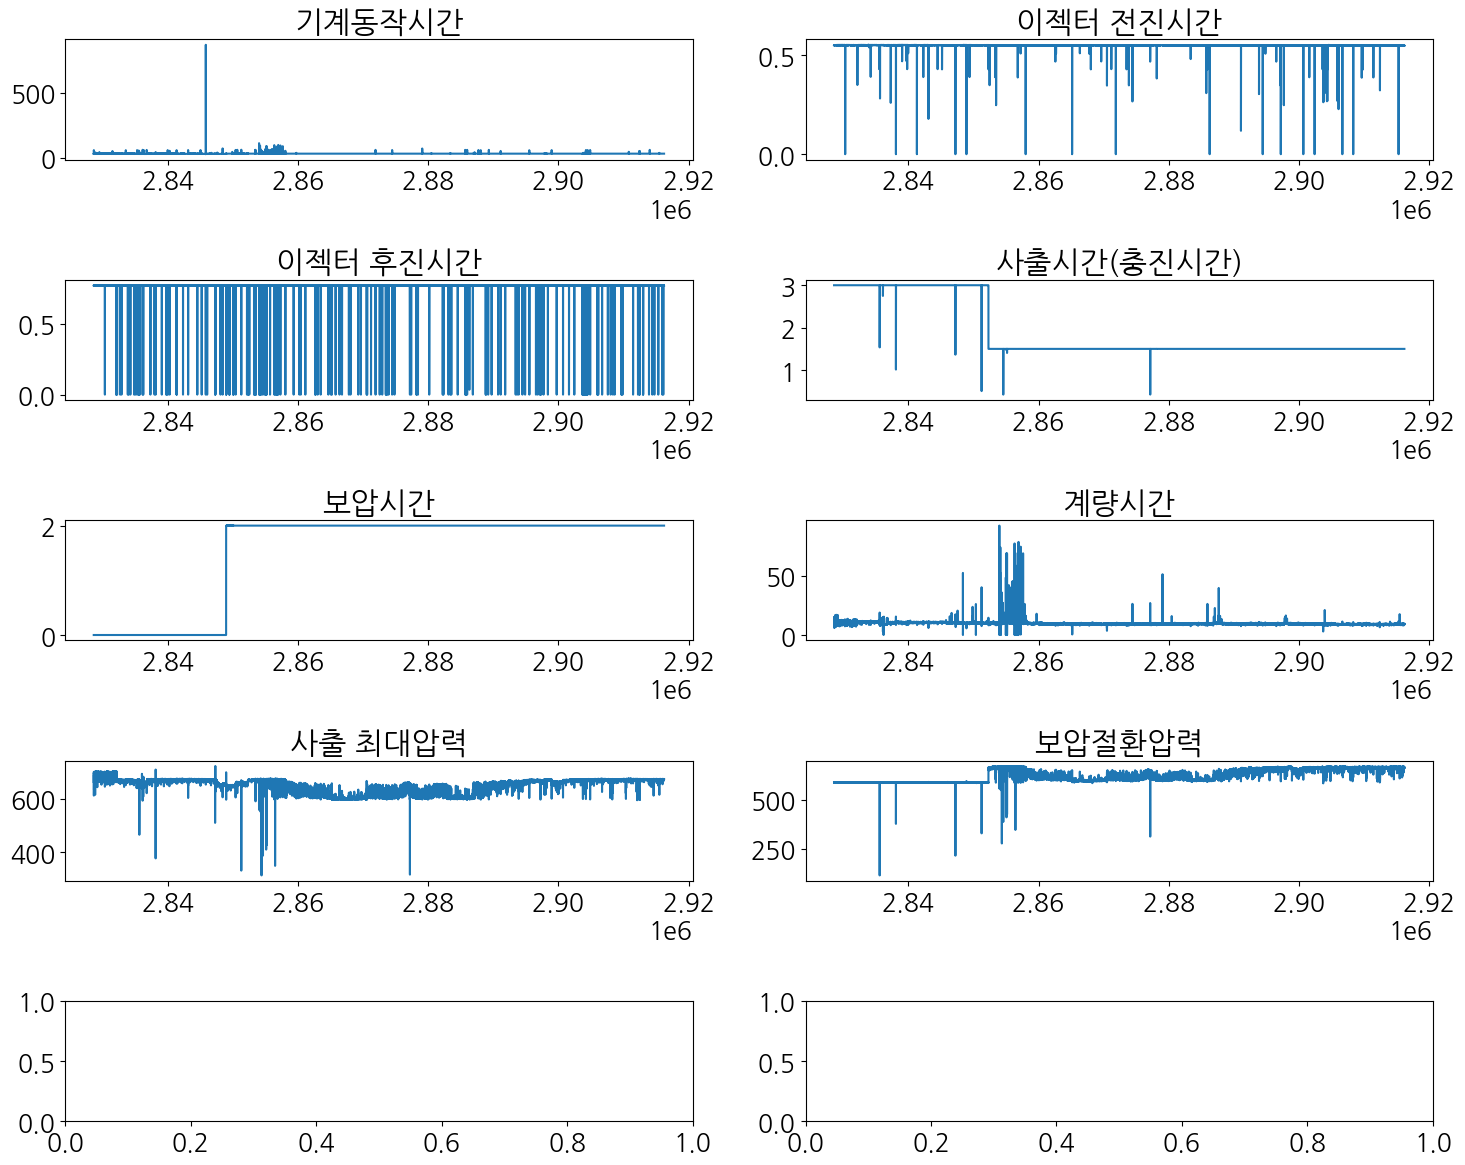

In [182]:
fig, axes = plt.subplots(5, 2, figsize=(15, 12))

for i, column in enumerate(dfTT1.columns):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    ax.plot(dfTT1[column])
    ax.set_title(f'{column}')

# 그래프 간 간격 조절
plt.tight_layout()

# 그래프 표시
plt.show()

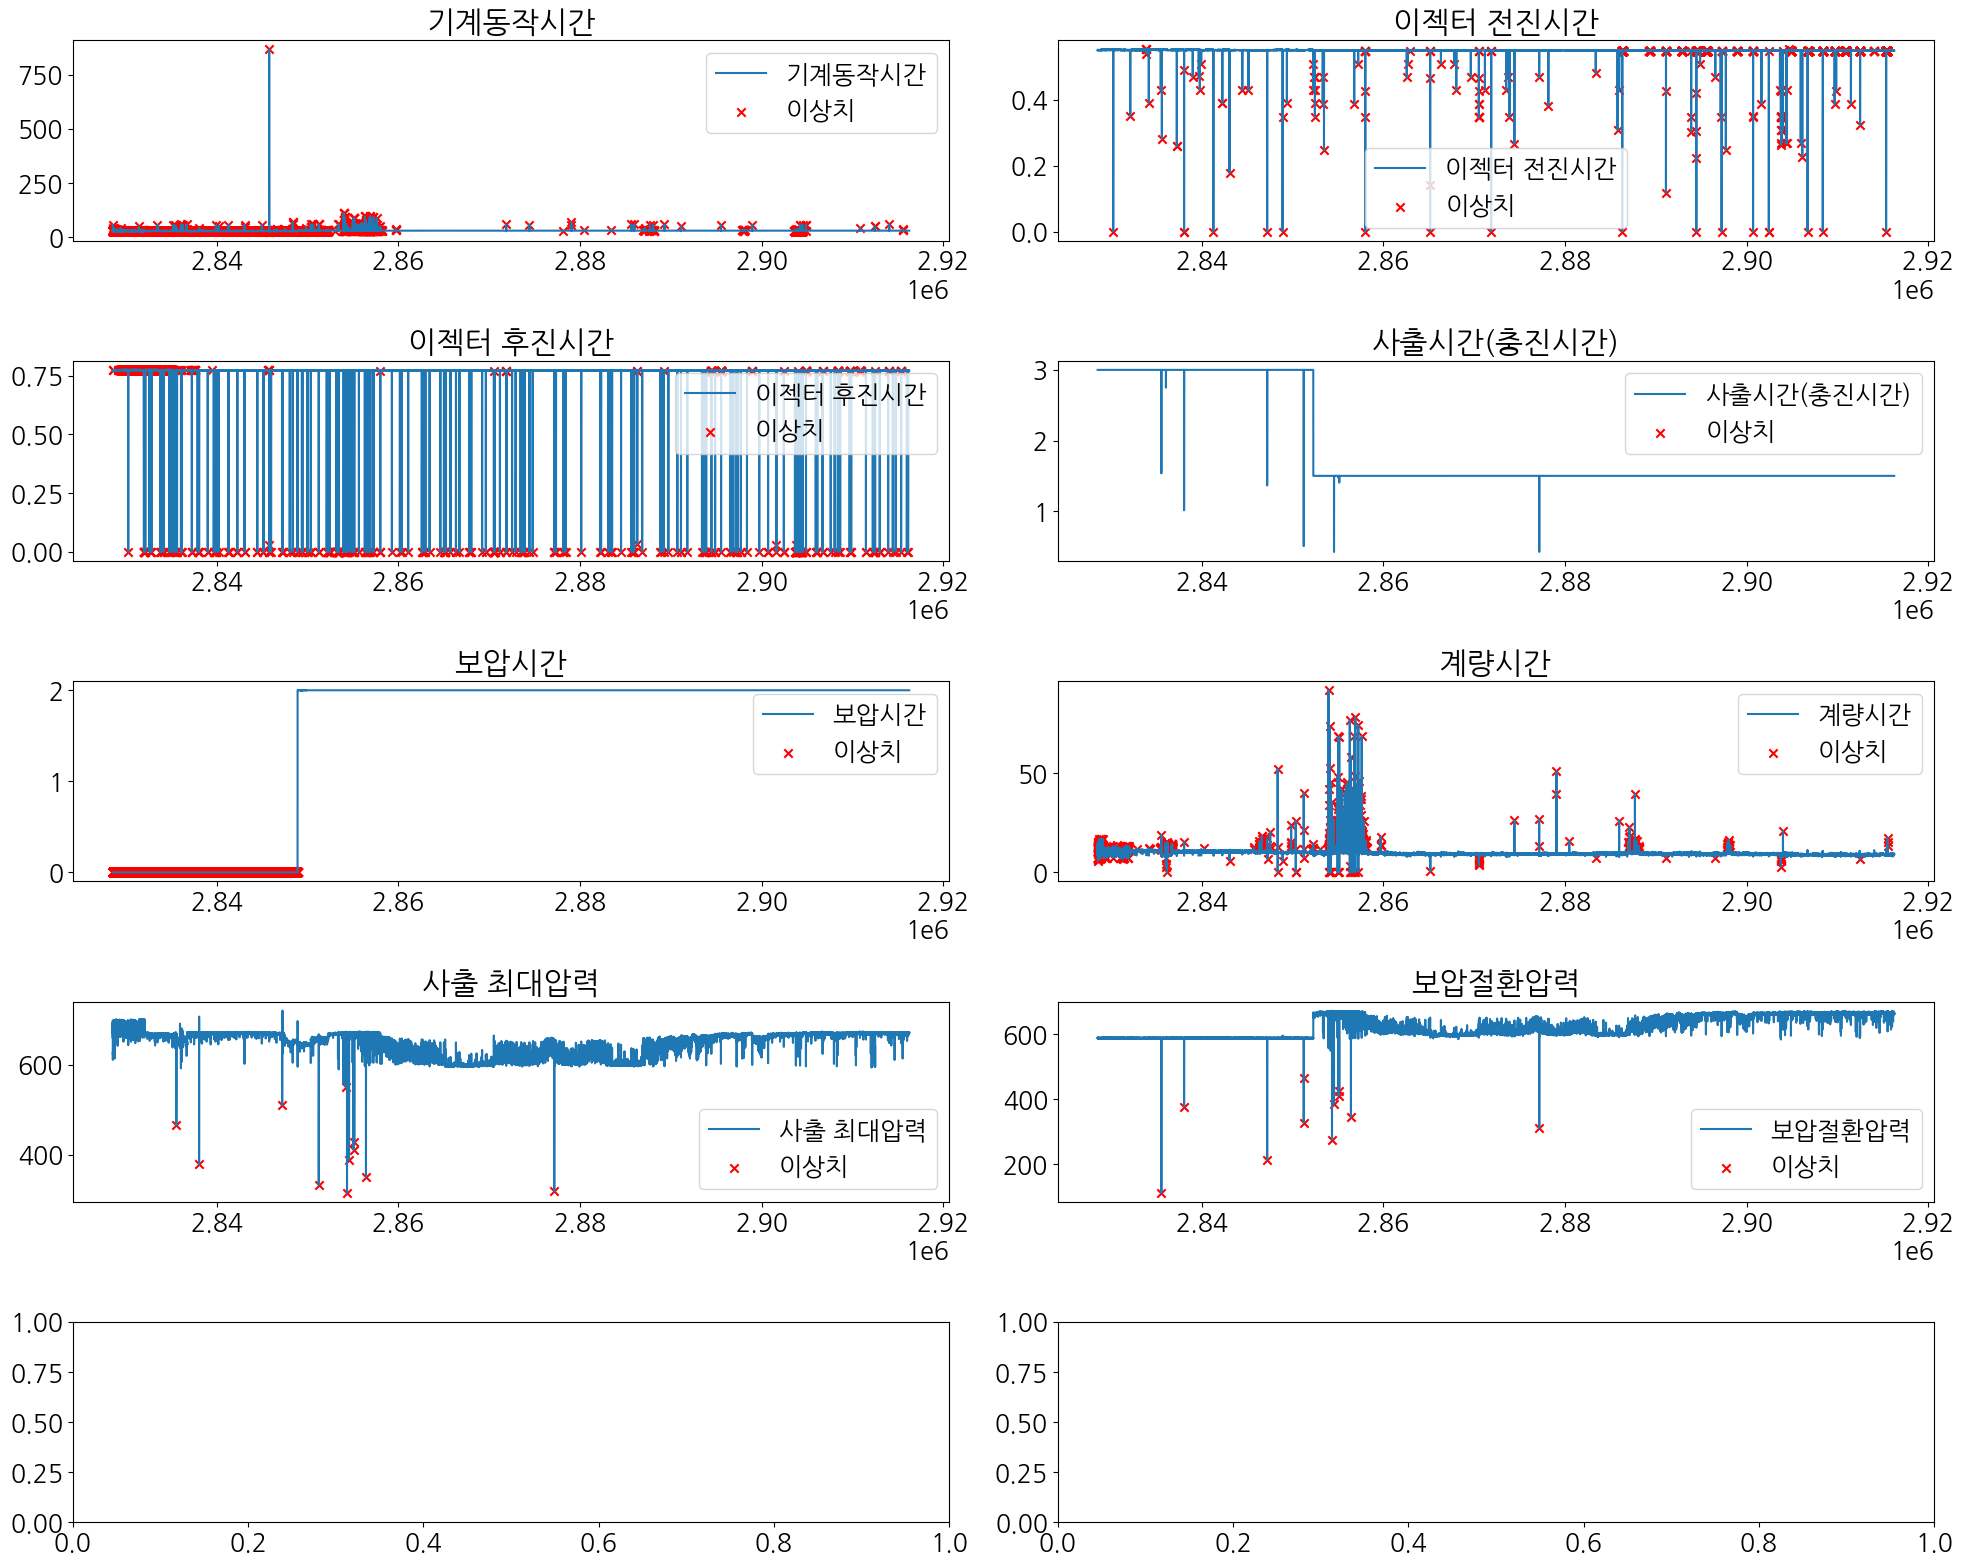

In [183]:
# 2행 2열로 선형 그래프 그리기
fig, axes = plt.subplots(5, 2, figsize=(20, 16))

for i, column in enumerate(dfTT1.columns):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    # 각 열에 대한 선형 그래프 그리기
    ax.plot(dfTT1[column], label=column)

    # IQR을 사용하여 이상치 식별
    Q1 = dfTT1[column].quantile(0.25)
    Q3 = dfTT1[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 이상치를 'x'로 표시
    outliers = dfTT1[(dfTT1[column] < lower_bound) | (dfTT1[column] > upper_bound)]
    ax.scatter(outliers.index, outliers[column], marker='x', color='red', label='이상치')

    ax.set_title(f'{column}')
    ax.legend()

# 그래프 간 간격 조절
plt.tight_layout()

# 그래프 표시
plt.show()

## 상관 계수

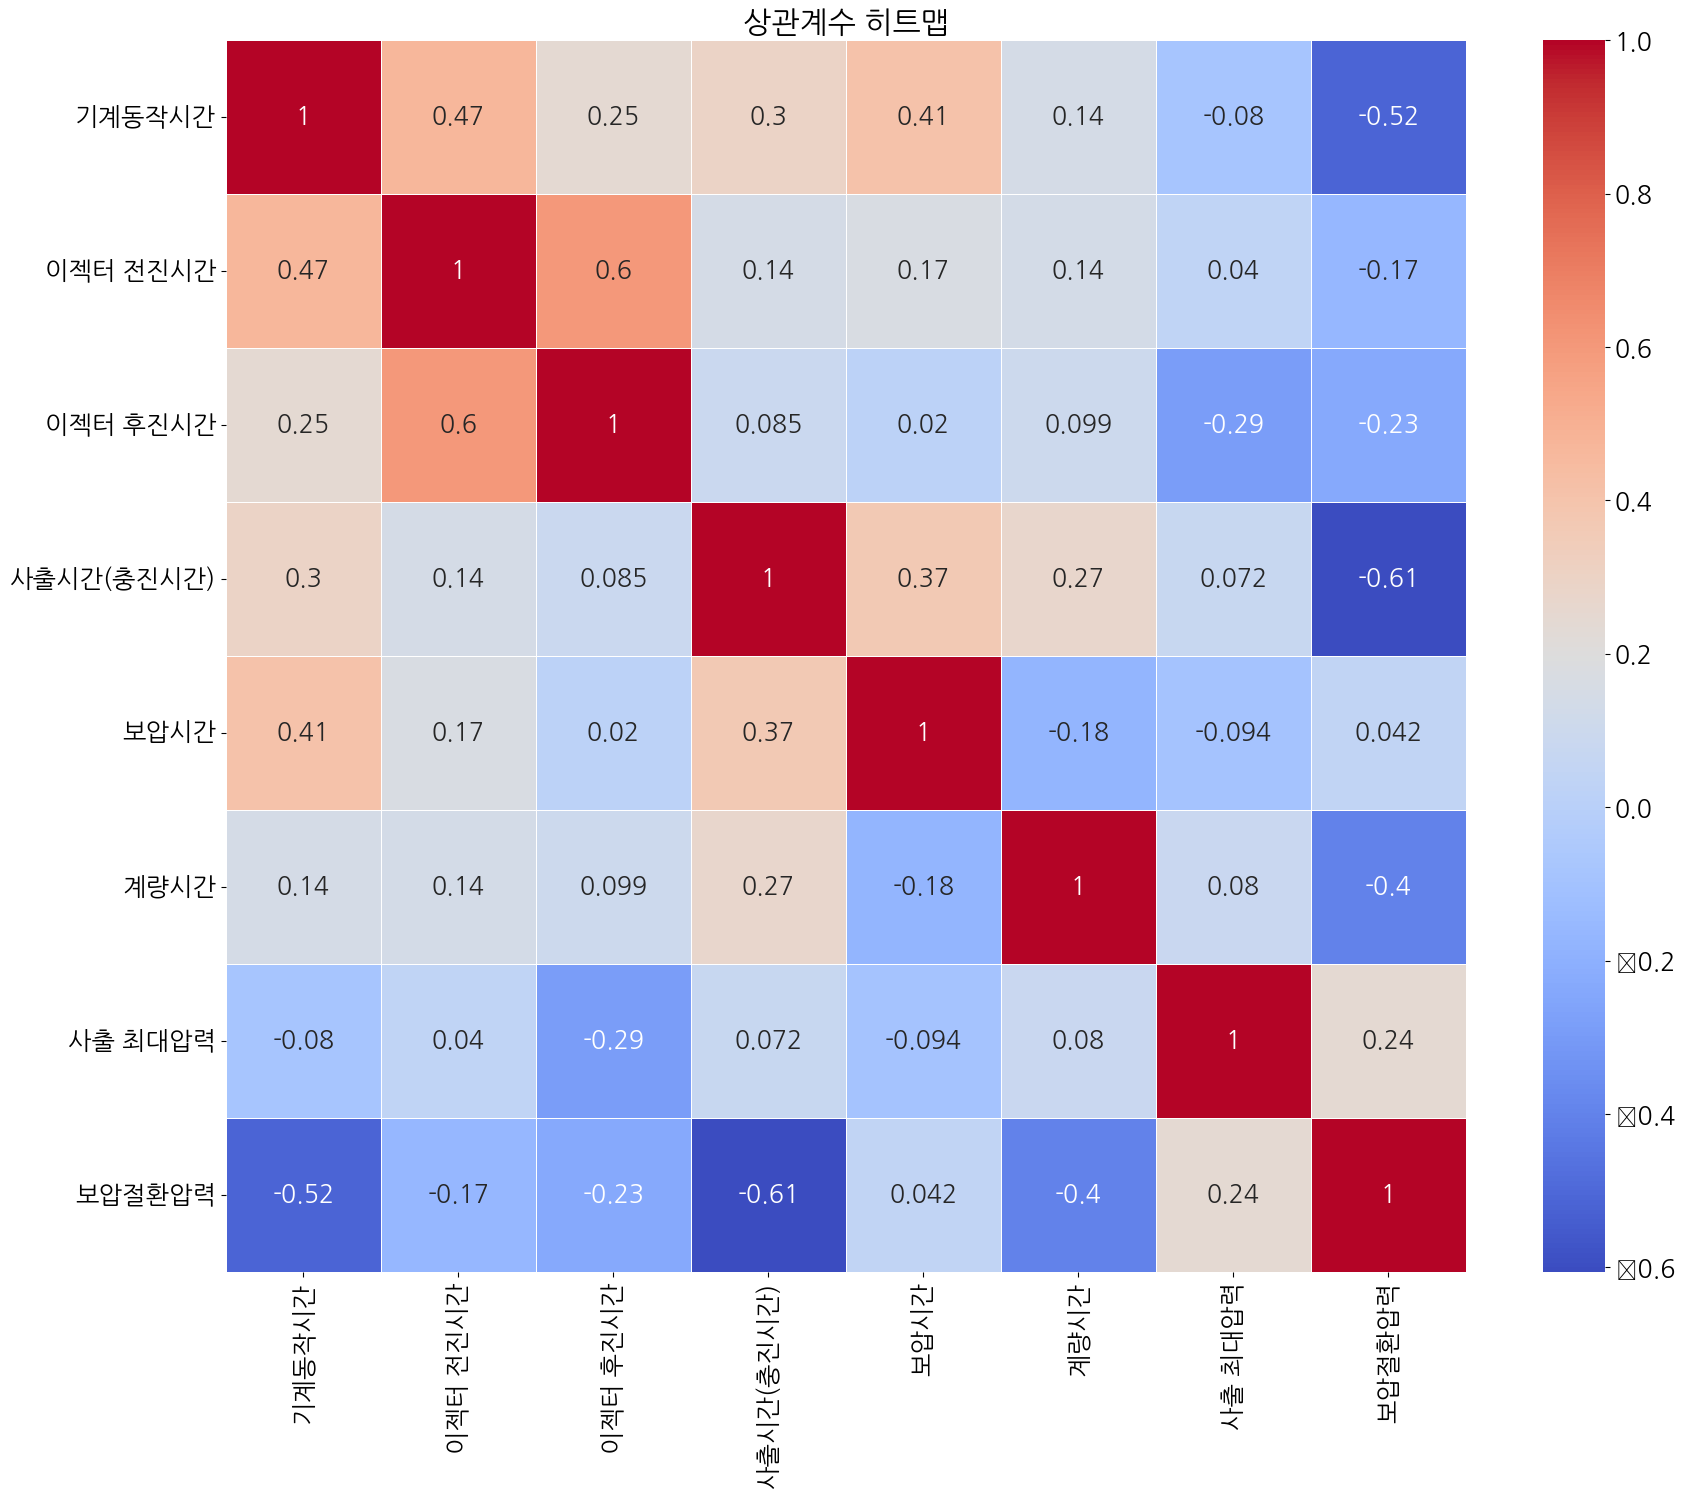

In [34]:
#상관 계수
import seaborn as sns

# 상관계수 행렬 생성
correlation_matrix = df.drop(['기기명','설비 이상신호'], axis=1).corr()

# 히트맵 그리기
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('상관계수 히트맵')
plt.show()


# 라벨링

In [185]:
da = df['배정번호']

KeyError: '배정번호'

In [ ]:
#df.drop(['기기명', '저장시간','형폐시간', '냉각시간'], inplace=True, axis=1)

df = dfTT1.drop(['형폐시간', '냉각시간'],axis=1)

In [8]:
df_name= df['기기명']

In [9]:
df.drop(['기기명'], axis=1, inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3165639 entries, 0 to 3165638
Data columns (total 12 columns):
 #   Column      Dtype  
---  ------      -----  
 0   저장시간        object 
 1   기계동작시간      float64
 2   형폐시간        float64
 3   이젝터 전진시간    float64
 4   이젝터 후진시간    float64
 5   사출시간(충진시간)  float64
 6   보압시간        float64
 7   계량시간        float64
 8   사출 최대압력     float64
 9   보압절환압력      float64
 10  냉각시간        float64
 11  IQR이상치개수    int64  
dtypes: float64(10), int64(1), object(1)
memory usage: 289.8+ MB


## IQR

In [13]:
df['IQR이상치개수'] =0
for col in df.columns:
    thirdq, firstq = df[col].quantile(0.75), df[col].quantile(0.25)
    interquartilerange = 1.5 * (thirdq - firstq)
    outlierhigh, outlierlow = interquartilerange + thirdq, firstq - interquartilerange

    outlier_indices = df[(df[col] > outlierhigh) | (df[col] < outlierlow)].index
    for idx in outlier_indices:
        df.loc[idx, 'IQR이상치개수'] += 1
print(df['IQR이상치개수'].value_counts())

IQR이상치개수
0    2049168
1     610387
4     172659
5     162167
2     140640
6      30614
7          4
Name: count, dtype: int64


## z-score

In [14]:
from scipy.stats import zscore

# z-score 계산
z_scores = np.abs(zscore(df))

# z-score가 3보다 큰 값을 이상치로 판단
df['z-score이상치개수'] = (z_scores > 3).sum(axis=1)

#df['anomaly'] = np.where(da['z-score이상치개수'] < 11, 1, -1)
print(df['z-score이상치개수'].value_counts())

z-score이상치개수
0    2822712
1     208389
2      70754
3      59880
4       3884
5         20
Name: count, dtype: int64


## 라벨링

In [101]:
df['z_anomaly'] = np.where(df['z-score이상치개수'] < 4, 0, 1)
df['IQR_anomaly'] =np.where(df['IQR이상치개수'] < 5, 0, 1)

In [102]:
df['설비 이상신호'] = np.where(((df['IQR_anomaly']==1) & (df['z_anomaly']==1)), 1, 0)

#['설비 이상신호']

In [103]:
df.head()
dd = df.drop(['IQR이상치개수', 'z-score이상치개수','z_anomaly','IQR_anomaly'], axis=1)

104126

In [90]:
print(dd['설비 이상신호'].value_counts())

설비 이상신호
0    3161735
1       3904
Name: count, dtype: int64


In [92]:
dd['기기명']= df_name

In [94]:
df_TT1 = dd[dd['기기명'] == 'TT1']
df_TT2 = dd[dd['기기명'] == 'TT2']
df_TT3 = dd[dd['기기명'] == 'TT3']
df_TT4 = dd[dd['기기명'] == 'TT4']
df_TT5 = dd[dd['기기명'] == 'TT5']
df_TT6 = dd[dd['기기명'] == 'TT6']
df_HK1 = dd[dd['기기명'] == 'HK1']

y_HK1 = df_HK1['설비 이상신호']
x_HK1 = df_HK1.drop(['설비 이상신호','기기명'], axis=1)

y_tt1 = df_TT1['설비 이상신호']
x_tt1 = df_TT1.drop(['설비 이상신호','기기명'], axis=1)

y_tt2 = df_TT2['설비 이상신호']
x_tt2 = df_TT2.drop(['설비 이상신호','기기명'], axis=1)

y_tt3 = df_TT3['설비 이상신호']
x_tt3 = df_TT3.drop(['설비 이상신호','기기명'], axis=1)

y_tt4 = df_TT4['설비 이상신호']
x_tt4 = df_TT4.drop(['설비 이상신호','기기명'], axis=1)


y_tt5 = df_TT5['설비 이상신호']
x_tt5 = df_TT5.drop(['설비 이상신호','기기명'], axis=1)

y_tt6 = df_TT6['설비 이상신호']
x_tt6 = df_TT6.drop(['설비 이상신호','기기명'], axis=1)


In [80]:
print(y.value_counts())

NameError: name 'y' is not defined

## TSNE 분석

In [67]:
#MC-TSNE
tsne = TSNE(n_jobs= -1)



#CU-TSNE
#from tsnecuda import TSNE
#X_embedded = TSNE(n_components=2, perplexity=15).fit_transform(x)

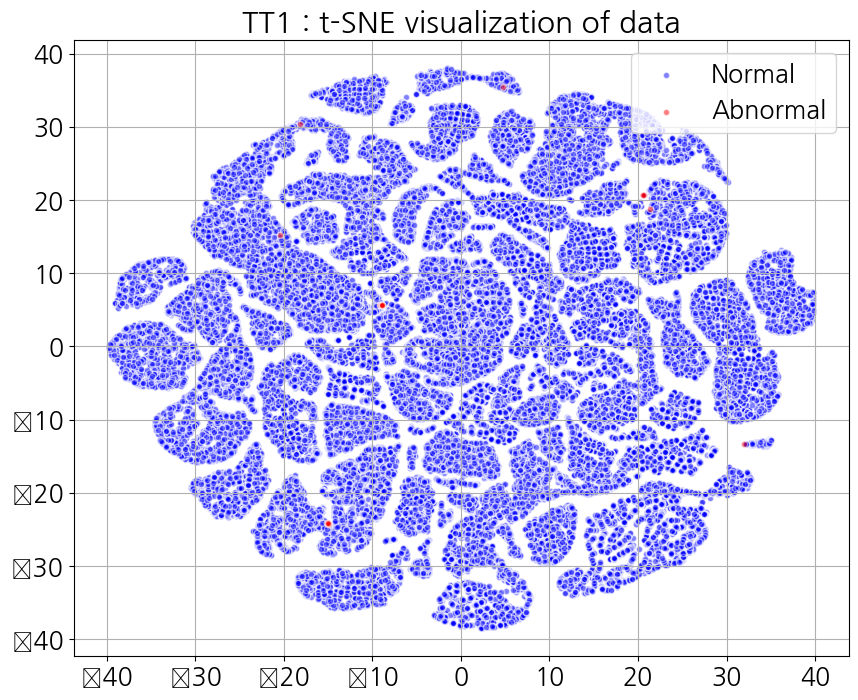

In [95]:
X_tsne_TT1 = tsne.fit_transform(x_tt1)

# Plot the results
plt.figure(figsize=(10, 8))

# Create a scatter plot for normal and abnormal points
plt.scatter(X_tsne_TT1[y_tt1 == 0, 0], X_tsne_TT1[y_tt1 == 0, 1], c='blue', label='Normal', edgecolors='w', s=20, alpha = 0.5)
plt.scatter(X_tsne_TT1[y_tt1 == 1, 0], X_tsne_TT1[y_tt1 == 1, 1], c='red', label='Abnormal', edgecolors='w', s=20, alpha = 0.5)

plt.legend(loc="upper right")
plt.title('TT1 : t-SNE visualization of data')
plt.grid(True)
plt.savefig('./tsne_tt1_cl35.png')
plt.show()


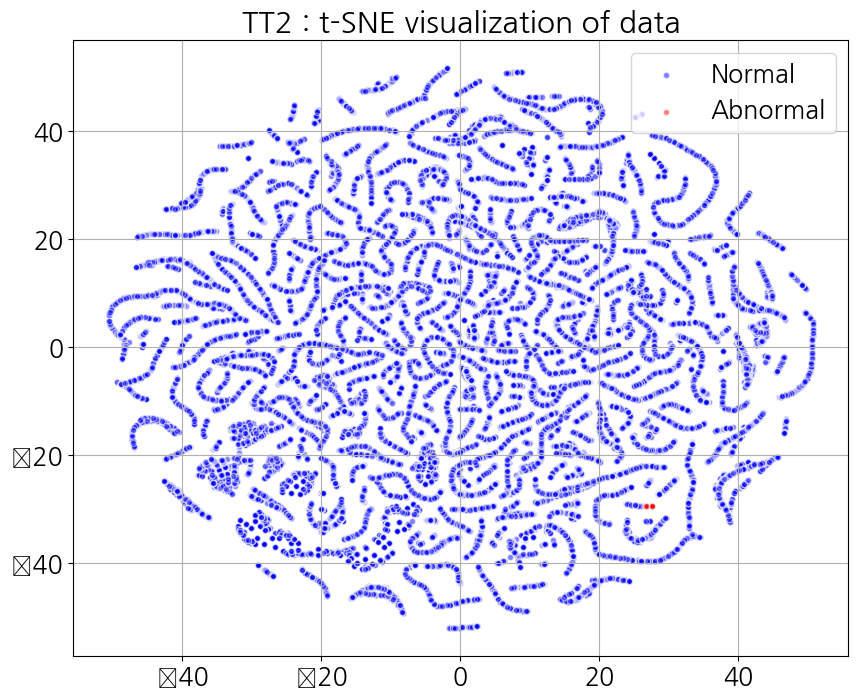

In [96]:
X_tsne_TT2 = tsne.fit_transform(x_tt2)
# Plot the results
plt.figure(figsize=(10, 8))

# Create a scatter plot for normal and abnormal points
plt.scatter(X_tsne_TT2[y_tt2 == 0, 0], X_tsne_TT2[y_tt2 == 0, 1], c='blue', label='Normal', edgecolors='w', s=20, alpha = 0.5)
plt.scatter(X_tsne_TT2[y_tt2 == 1, 0], X_tsne_TT2[y_tt2 == 1, 1], c='red', label='Abnormal', edgecolors='w', s=20, alpha = 0.5)

plt.legend(loc="upper right")
plt.title('TT2 : t-SNE visualization of data')
plt.grid(True)
plt.savefig('./th_tsneTT2_cl35.png')
plt.show()


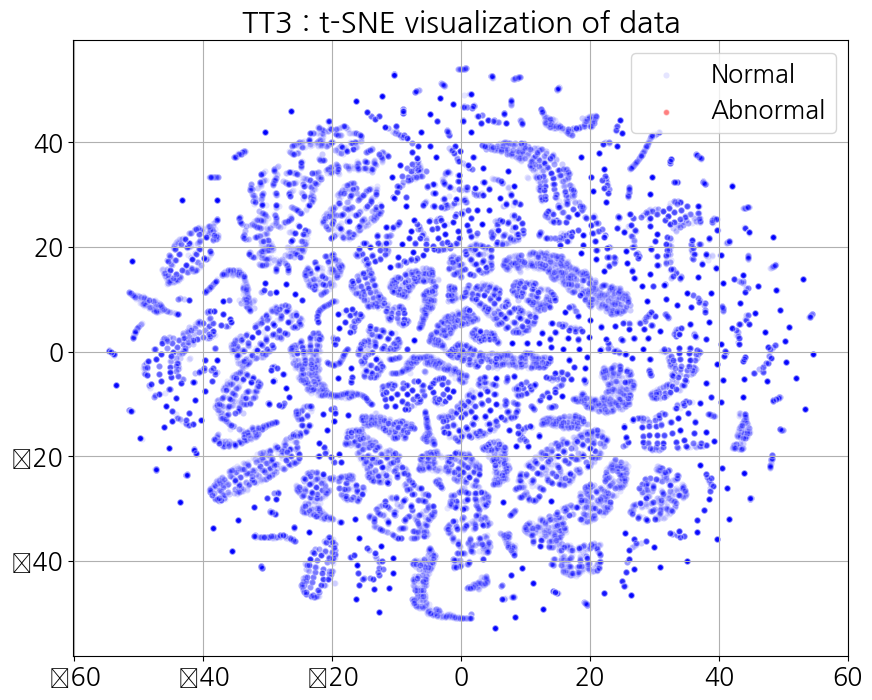

In [97]:
X_tsne_TT3 = tsne.fit_transform(x_tt3)
# Plot the results
plt.figure(figsize=(10, 8))

# Create a scatter plot for normal and abnormal points
plt.scatter(X_tsne_TT3[y_tt3 == 0, 0], X_tsne_TT3[y_tt3 == 0, 1], c='blue', label='Normal', edgecolors='w', s=20, alpha = 0.1)
plt.scatter(X_tsne_TT3[y_tt3 == 1, 0], X_tsne_TT3[y_tt3 == 1, 1], c='red', label='Abnormal', edgecolors='w', s=20, alpha = 0.5)

plt.legend(loc="upper right")
plt.title('TT3 : t-SNE visualization of data')
plt.grid(True)
plt.savefig('./th_tsneTT3_cl35.png')
plt.show()


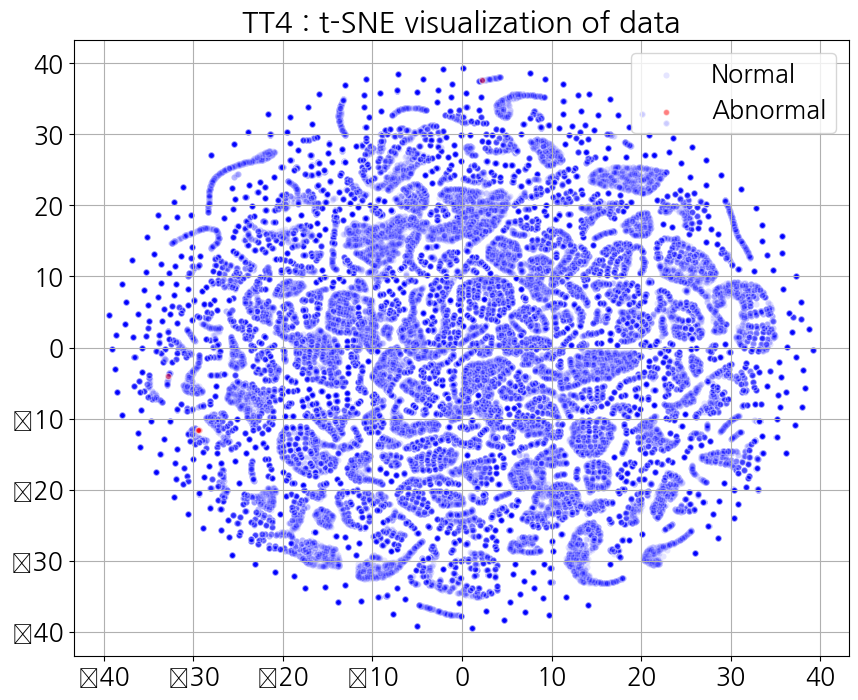

In [98]:
X_tsne_TT4 = tsne.fit_transform(x_tt4)
# Plot the results
plt.figure(figsize=(10, 8))

# Create a scatter plot for normal and abnormal points
plt.scatter(X_tsne_TT4[y_tt4 == 0, 0], X_tsne_TT4[y_tt4 == 0, 1], c='blue', label='Normal', edgecolors='w', s=20, alpha = 0.1)
plt.scatter(X_tsne_TT4[y_tt4 == 1, 0], X_tsne_TT4[y_tt4 == 1, 1], c='red', label='Abnormal', edgecolors='w', s=20, alpha = 0.5)

plt.legend(loc="upper right")
plt.title('TT4 : t-SNE visualization of data')
plt.grid(True)
plt.savefig('./th_tsneTT4_cl35.png')
plt.show()


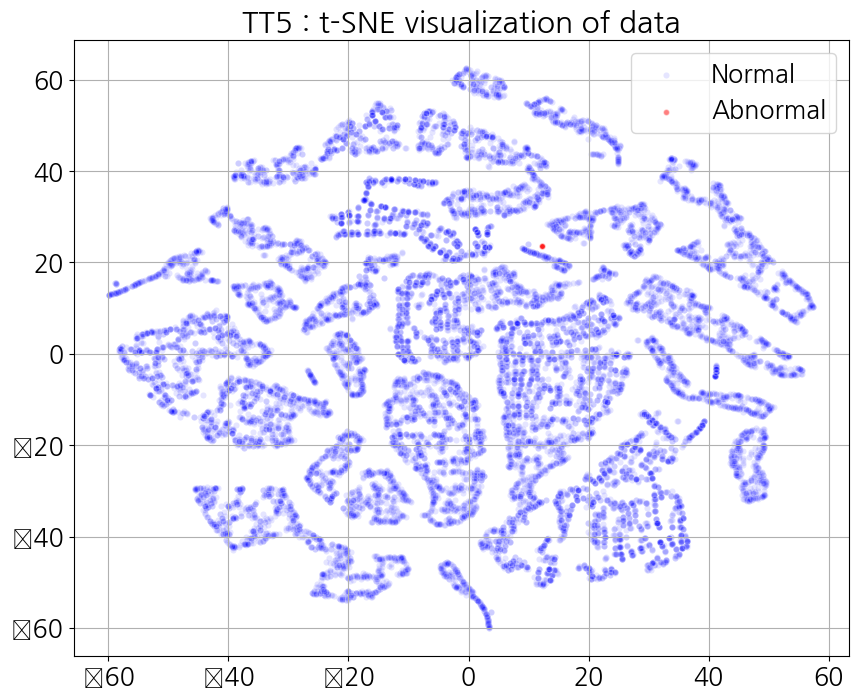

In [99]:
X_tsne_TT5 = tsne.fit_transform(x_tt5)
# Plot the results
plt.figure(figsize=(10, 8))

# Create a scatter plot for normal and abnormal points
plt.scatter(X_tsne_TT5[y_tt5 == 0, 0], X_tsne_TT5[y_tt5 == 0, 1], c='blue', label='Normal', edgecolors='w', s=20, alpha = 0.1)
plt.scatter(X_tsne_TT5[y_tt5 == 1, 0], X_tsne_TT5[y_tt5 == 1, 1], c='red', label='Abnormal', edgecolors='w', s=20, alpha = 0.5)

plt.legend(loc="upper right")
plt.title('TT5 : t-SNE visualization of data')
plt.grid(True)
plt.savefig('./th_tsneTT5_cl35.png')
plt.show()


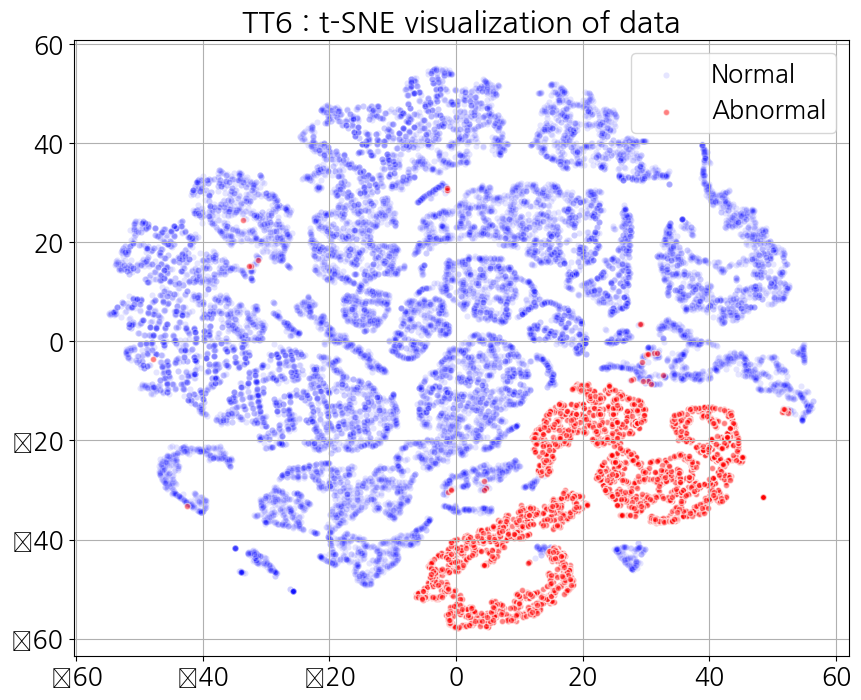

In [100]:
X_tsne_TT6 = tsne.fit_transform(x_tt6)
# Plot the results
plt.figure(figsize=(10, 8))

# Create a scatter plot for normal and abnormal points
plt.scatter(X_tsne_TT6[y_tt6 == 0, 0], X_tsne_TT6[y_tt6 == 0, 1], c='blue', label='Normal', edgecolors='w', s=20, alpha = 0.1)
plt.scatter(X_tsne_TT6[y_tt6 == 1, 0], X_tsne_TT6[y_tt6 == 1, 1], c='red', label='Abnormal', edgecolors='w', s=20, alpha = 0.5)

plt.legend(loc="upper right")
plt.title('TT6 : t-SNE visualization of data')
plt.grid(True)
plt.savefig('./th_tsneTT6_cl35.png')
plt.show()


In [ ]:
X_tsne_HK1 = tsne.fit_transform(x_HK1)
# Plot the results
plt.figure(figsize=(10, 8))

# Create a scatter plot for normal and abnormal points
plt.scatter(X_tsne_HK1[y_HK1 == 0, 0], X_tsne_HK1[y_HK1 == 0, 1], c='blue', label='Normal', edgecolors='w', s=20, alpha = 0.1)
plt.scatter(X_tsne_HK1[y_HK1 == 1, 0], X_tsne_HK1[y_HK1 == 1, 1], c='red', label='Abnormal', edgecolors='w', s=20, alpha = 0.5)

plt.legend(loc="upper right")
plt.title('HK1 :  t-SNE visualization of data')
plt.grid(True)
plt.savefig('./th_tsneHK1_cl.png')
plt.show()
